# App User Behavior Segmentation

## Project Objective

This project applies **unsupervised machine learning** to segment app users based on behavioral patterns.

The notebook follows the complete project approach:

1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Feature Selection
5. Data Scaling
6. Clustering Model Selection
7. Optimal Cluster Identification
8. Cluster Assignment
9. Cluster-Level User Identification & Profiling
10. Business Insight Generation & Customer Action Mapping

The final outcome is four business-facing segments:

- **High Users**
- **Moderate Users**
- **Low Users**
- **Occasional Users**

The segment names are **not assigned from the K-Means cluster number**. K-Means cluster IDs are arbitrary. Instead, the notebook evaluates the behavioral performance of each cluster and then assigns the business-facing name.

## Project Folder Structure

The notebook is designed to be stored in the `notebooks` folder while the dataset remains in the `data` folder.

```text
app-user-behavior-segmentation/
│
├── data/
│   └── app_user_behavior_dataset.csv
│
├── notebooks/
│   └── app_user_behavior_segmentation_clean.ipynb
│
├── models/
├── outputs/
└── app.py
```

The dataset path used by this notebook is:

`../data/app_user_behavior_dataset.csv`

## 1. Data Collection

Load the app user behavior dataset from the project's `data` folder. The notebook does not require the CSV to be copied into the notebook folder.

In [29]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "app_user_behavior_dataset.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Make sure the CSV is stored in the project's data folder."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Dataset loaded successfully: 50,000 rows x 21 columns


,user_id,age,gender,country,device_type,subscription_type,days_active,total_sessions,avg_session_duration_min,screen_views,clicks,likes,shares,comments,searches,notifications_received,notification_open_rate,purchases,total_spend,retained_30d,churn_risk_score
0,U00001,56.0,Female,India,iOS,Basic,96,22,4.49,107,10,1,0,0,9,24,0.122,4,59.82,0,0.448
1,U00002,46.0,Female,India,Android,Free,111,27,7.75,268,42,18,3,4,11,142,0.435,0,0.00,0,0.325
2,U00003,32.0,Male,India,Android,Basic,56,22,15.89,129,27,3,0,0,13,12,0.198,3,95.08,0,0.608
3,U00004,60.0,Female,India,Android,Free,183,26,9.18,201,33,6,1,1,11,12,0.452,0,0.00,1,0.129
4,U00005,25.0,Male,USA,Android,Free,153,28,15.08,126,24,3,0,1,10,35,0.441,1,30.97,1,0.000


## 2. Data Understanding

Explore the structure, data types, missing values, duplicate records, unique users, and numerical distributions.

In [30]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Shape: (50000, 21)

Column names:
['user_id', 'age', 'gender', 'country', 'device_type', 'subscription_type', 'days_active', 'total_sessions', 'avg_session_duration_min', 'screen_views', 'clicks', 'likes', 'shares', 'comments', 'searches', 'notifications_received', 'notification_open_rate', 'purchases', 'total_spend', 'retained_30d', 'churn_risk_score']

Data types:


,dtype
user_id,str
age,float64
gender,str
country,str
device_type,str
subscription_type,str
days_active,int64
total_sessions,int64
avg_session_duration_min,float64
screen_views,int64



Missing values:


,missing_values
avg_session_duration_min,750
notification_open_rate,500
age,500
country,250
user_id,0
device_type,0
gender,0
days_active,0
subscription_type,0
screen_views,0



Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,50000,50000,U00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,49500.0,NaN,NaN,NaN,38.986687,12.360933,18.0,28.0,39.0,50.0,60.0
gender,50000,3,Female,24167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,49750,7,India,14681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,50000,2,Android,29128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,50000,3,Free,27342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_active,50000.0,NaN,NaN,NaN,112.13022,61.97794,3.0,66.0,101.0,146.0,365.0
total_sessions,50000.0,NaN,NaN,NaN,25.23082,5.115442,4.0,22.0,25.0,29.0,51.0
avg_session_duration_min,49250.0,NaN,NaN,NaN,12.020197,4.951734,1.0,8.6,12.01,15.38,33.51
screen_views,50000.0,NaN,NaN,NaN,180.72038,67.49392,1.0,133.0,175.0,223.0,537.0


In [31]:
# Identify the user ID column.
USER_ID_CANDIDATES = [
    "user_id", "userid", "user id", "customer_id", "customerid", "customer id"
]

def resolve_column(dataframe, candidates):
    normalized = {
        str(c).strip().lower().replace(" ", "_"): c
        for c in dataframe.columns
    }
    for candidate in candidates:
        key = candidate.strip().lower().replace(" ", "_")
        if key in normalized:
            return normalized[key]
    return None

USER_ID_COL = resolve_column(df, USER_ID_CANDIDATES)

if USER_ID_COL is None:
    # Fall back to the first column that looks like an identifier.
    id_like = [
        c for c in df.columns
        if "user" in str(c).lower() and "id" in str(c).lower()
    ]
    USER_ID_COL = id_like[0] if id_like else df.columns[0]

print("User ID column:", USER_ID_COL)
print("Unique users:", df[USER_ID_COL].nunique())

User ID column: user_id
Unique users: 50000


## 3. Data Cleaning

The dataset is cleaned without deleting useful users unnecessarily.

- Duplicate records are removed.
- Numerical columns are converted where possible.
- Missing numerical values are replaced with the median.
- Missing categorical values are replaced with the mode.
- Infinite values are converted to missing before imputation.

The cleaned dataset is retained separately so the original loaded data remains traceable.

In [32]:
df_clean = df.copy()

# Remove exact duplicate rows.
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicate rows: {before - len(df_clean):,}")

# Convert obvious numeric columns where possible.
for col in df_clean.columns:
    if col == USER_ID_COL:
        continue
    if df_clean[col].dtype == "object":
        converted = pd.to_numeric(df_clean[col], errors="coerce")
        # Convert only when most non-null values are numeric.
        original_non_null = df_clean[col].notna().sum()
        converted_non_null = converted.notna().sum()
        if original_non_null > 0 and converted_non_null / original_non_null >= 0.90:
            df_clean[col] = converted

# Replace infinities.
numeric_cols_all = df_clean.select_dtypes(include=np.number).columns
df_clean[numeric_cols_all] = df_clean[numeric_cols_all].replace([np.inf, -np.inf], np.nan)

# Impute numeric columns using median.
for col in numeric_cols_all:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute categorical columns using mode.
categorical_cols = df_clean.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    if df_clean[col].isna().any():
        mode = df_clean[col].mode()
        df_clean[col] = df_clean[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

print("Remaining missing values:", int(df_clean.isna().sum().sum()))
display(df_clean.head())

Removed duplicate rows: 0
Remaining missing values: 0


,user_id,age,gender,country,device_type,subscription_type,days_active,total_sessions,avg_session_duration_min,screen_views,clicks,likes,shares,comments,searches,notifications_received,notification_open_rate,purchases,total_spend,retained_30d,churn_risk_score
0,U00001,56.0,Female,India,iOS,Basic,96,22,4.49,107,10,1,0,0,9,24,0.122,4,59.82,0,0.448
1,U00002,46.0,Female,India,Android,Free,111,27,7.75,268,42,18,3,4,11,142,0.435,0,0.00,0,0.325
2,U00003,32.0,Male,India,Android,Basic,56,22,15.89,129,27,3,0,0,13,12,0.198,3,95.08,0,0.608
3,U00004,60.0,Female,India,Android,Free,183,26,9.18,201,33,6,1,1,11,12,0.452,0,0.00,1,0.129
4,U00005,25.0,Male,USA,Android,Free,153,28,15.08,126,24,3,0,1,10,35,0.441,1,30.97,1,0.000


## 4. Feature Selection

Select behavioral variables for clustering. Demographic, device, location, ID, and already-created target/segment fields are excluded from the clustering input.

The resolver below works with common column-name variations, so the notebook remains usable if capitalization or underscores differ.

In [33]:
# Common behavioral feature aliases.
FEATURE_GROUPS = {
    "activity": [
        "days_active", "active_days", "days_active_per_week",
        "total_sessions", "sessions", "session_frequency", "sessions_per_week",
        "avg_session_duration_min", "average_session_duration",
        "daily_active_minutes", "active_minutes",
        "screen_views", "page_views",
        "clicks", "likes", "shares", "comments", "searches",
        "notification_open_rate"
    ],
    "value": [
        "purchases", "purchase_count", "total_purchases",
        "total_spend", "spend", "total_spending", "revenue"
    ],
    "retention": [
        "retention_30d", "retained_30d", "30_day_retention",
        "churn_risk_score", "churn_risk"
    ],
    "engagement": [
        "engagement_score"
    ]
}

excluded_terms = [
    "user_id", "userid", "customer_id", "customerid",
    "cluster", "segment", "label", "target", "class"
]

def resolve_any(dataframe, aliases):
    return resolve_column(dataframe, aliases)

selected_features = []

for group, aliases in FEATURE_GROUPS.items():
    for alias in aliases:
        col = resolve_any(df_clean, [alias])
        if col is not None and col not in selected_features:
            selected_features.append(col)

# Keep only numeric behavioral features.
selected_features = [
    c for c in selected_features
    if pd.api.types.is_numeric_dtype(df_clean[c])
    and not any(term in str(c).lower() for term in excluded_terms)
]

# If the expected aliases are unavailable, use numeric columns as a safe fallback.
if len(selected_features) < 4:
    numeric_candidates = [
        c for c in df_clean.select_dtypes(include=np.number).columns
        if c != USER_ID_COL
        and not any(term in str(c).lower() for term in excluded_terms)
    ]
    selected_features = numeric_candidates

# Remove zero-variance features.
selected_features = [
    c for c in selected_features
    if df_clean[c].nunique(dropna=False) > 1
]

if len(selected_features) < 2:
    raise ValueError("At least two numeric behavioral features are required for clustering.")

print("Selected clustering features:")
for feature in selected_features:
    print(" -", feature)

X = df_clean[selected_features].copy()
display(X.describe().T)

Selected clustering features:
 - days_active
 - total_sessions
 - avg_session_duration_min
 - screen_views
 - clicks
 - likes
 - shares
 - comments
 - searches
 - notification_open_rate
 - purchases
 - total_spend
 - retained_30d
 - churn_risk_score


,count,mean,std,min,25%,50%,75%,max
days_active,50000.0,112.130220,61.977940,3.000,66.0000,101.000,146.0000,365.000
total_sessions,50000.0,25.230820,5.115442,4.000,22.0000,25.000,29.0000,51.000
avg_session_duration_min,50000.0,12.020044,4.914455,1.000,8.6575,12.010,15.3300,33.510
screen_views,50000.0,180.720380,67.493920,1.000,133.0000,175.000,223.0000,537.000
clicks,50000.0,33.833400,17.733264,0.000,20.0000,31.000,44.0000,132.000
likes,50000.0,7.993880,6.269117,0.000,3.0000,6.000,11.0000,53.000
shares,50000.0,0.641460,1.039582,0.000,0.0000,0.000,1.0000,11.000
comments,50000.0,1.064200,1.507051,0.000,0.0000,1.000,2.0000,17.000
searches,50000.0,12.007660,3.498149,2.000,10.0000,12.000,14.0000,32.000
notification_open_rate,50000.0,0.284571,0.151697,0.003,0.1680,0.265,0.3810,0.904


## 5. Data Scaling

Apply `StandardScaler` so features measured on different scales contribute comparably to K-Means distance calculations.

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features, index=df_clean.index)

print("Scaled feature matrix:", X_scaled.shape)
display(X_scaled_df.head())

Scaled feature matrix: (50000, 14)


,days_active,total_sessions,avg_session_duration_min,screen_views,clicks,likes,shares,comments,searches,notification_open_rate,purchases,total_spend,retained_30d,churn_risk_score
0,-0.260260,-0.631588,-1.532239,-1.092263,-1.344007,-1.115620,-0.617043,-0.706154,-0.859795,-1.071691,1.206152,-0.296226,-0.786208,0.591044
1,-0.018236,0.345854,-0.868883,1.293161,0.460529,1.596113,2.268762,1.948062,-0.288058,0.991654,-1.481053,-0.945805,-0.786208,-0.074883
2,-0.905657,-0.631588,0.787472,-0.766305,-0.385347,-0.796592,-0.617043,-0.706154,0.283679,-0.570687,0.534351,0.086659,-0.786208,1.457290
3,1.143479,0.150366,-0.577902,0.300469,-0.046997,-0.318051,0.344892,-0.042600,-0.288058,1.103721,-1.481053,-0.945805,1.271928,-1.136035
4,0.659431,0.541343,0.622650,-0.810753,-0.554523,-0.796592,-0.617043,-0.042600,-0.573926,1.031207,-0.809252,-0.609505,1.271928,-1.834446


## 6. Clustering Model Selection

Evaluate several K-Means cluster counts using inertia and silhouette score. This provides evidence for selecting the final number of clusters.

In [35]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

model_metrics = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(model_metrics)

,k,inertia,silhouette_score
0,2,581164.136103,0.193149
1,3,528726.875729,0.128420
2,4,494686.001982,0.121078
3,5,466602.478101,0.118201
4,6,447450.524236,0.108664
5,7,433128.398934,0.107636
6,8,421768.605151,0.094330


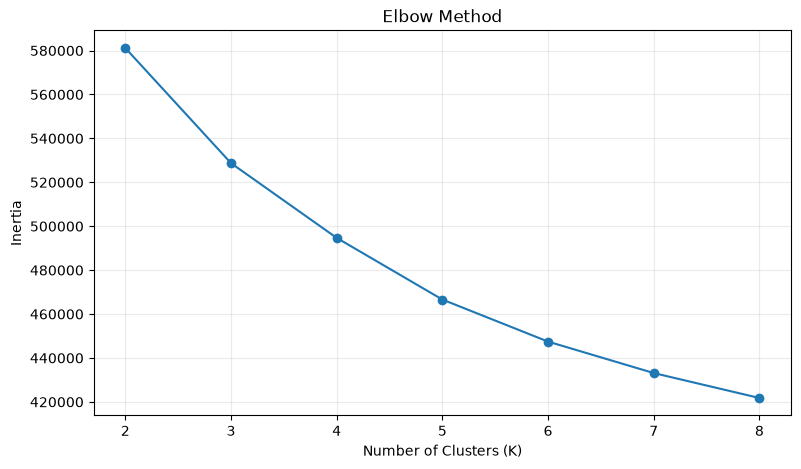

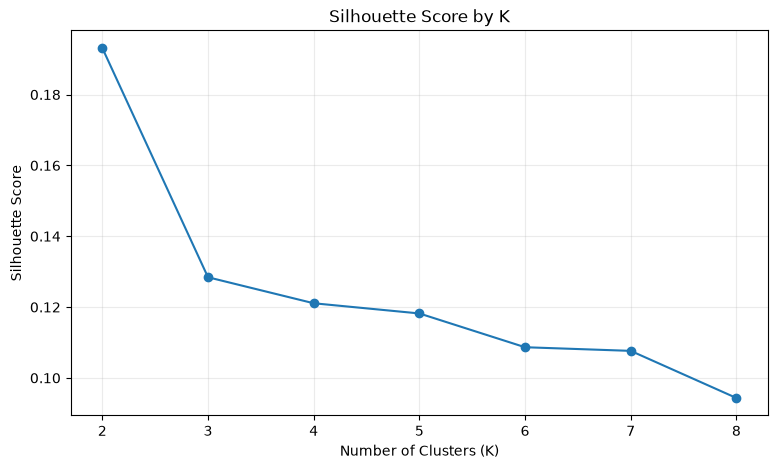

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(model_metrics["k"], model_metrics["inertia"], marker="o")
ax.set_title("Elbow Method")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia")
ax.set_xticks(list(k_values))
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(model_metrics["k"], model_metrics["silhouette_score"], marker="o")
ax.set_title("Silhouette Score by K")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(list(k_values))
ax.grid(alpha=0.25)
plt.show()

## 7. Optimal Cluster Identification

The project requirement is to produce **four behavioral segments**. Therefore, the final model uses **K = 4** after reviewing the model-selection metrics.

The Elbow and Silhouette outputs above are retained as supporting evidence rather than allowing the cluster numbers to become business labels.

In [37]:
FINAL_K = 4

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)
df_clean["cluster"] = cluster_labels

print("Final K-Means model trained.")
print("\nCluster counts:")
display(df_clean["cluster"].value_counts().sort_index().to_frame("users"))

Final K-Means model trained.

Cluster counts:


,users
cluster,
0,10297
1,19871
2,7295
3,12537


## 8. Cluster Assignment

Every user is assigned to exactly one K-Means cluster. At this stage, the numbers 0–3 are only technical cluster IDs. They do **not** yet mean High, Moderate, Low, or Occasional.

In [38]:
print("Unique clusters:", sorted(df_clean["cluster"].unique()))
print("Users without cluster assignment:", int(df_clean["cluster"].isna().sum()))

cluster_counts = (
    df_clean["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="user_count")
)

cluster_counts["percentage_of_users"] = (
    cluster_counts["user_count"] / len(df_clean) * 100
).round(2)

display(cluster_counts)

Unique clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
Users without cluster assignment: 0


,cluster,user_count,percentage_of_users
0,0,10297,20.59
1,1,19871,39.74
2,2,7295,14.59
3,3,12537,25.07


## 9. Cluster-Level User Identification & Profiling

Create a cluster profile using the average values of the selected behavioral features.

This step answers:

> **What does each technical K-Means cluster actually look like?**

The profile will later be used to assign the business-facing segment names.

In [39]:
cluster_profile = (
    df_clean.groupby("cluster")[selected_features]
    .mean()
    .round(3)
)

cluster_profile["user_count"] = df_clean.groupby("cluster")[USER_ID_COL].nunique()
cluster_profile["percentage_of_users"] = (
    cluster_profile["user_count"] / len(df_clean) * 100
).round(2)

display(cluster_profile)

,days_active,total_sessions,avg_session_duration_min,screen_views,clicks,likes,shares,comments,searches,notification_open_rate,purchases,total_spend,retained_30d,churn_risk_score,user_count,percentage_of_users
cluster,,,,,,,,,,,,,,,,
0,175.603,30.222,11.980,227.860,41.027,8.062,0.518,0.922,12.028,0.285,2.238,89.400,0.378,0.186,10297,20.59
1,89.020,23.027,11.981,151.071,26.248,5.494,0.302,0.562,12.012,0.285,2.194,85.879,0.000,0.496,19871,39.74
2,119.418,27.863,12.114,247.219,58.303,19.064,2.339,3.517,11.975,0.284,2.234,88.501,0.366,0.302,7295,14.59
3,92.386,23.092,12.060,150.303,25.710,5.459,0.294,0.550,12.003,0.283,2.177,86.329,1.000,0.237,12537,25.07


## 10. Dynamic Behavioral Segment Naming

K-Means does not know what a "High User" or "Low User" is. Cluster IDs are arbitrary.

The notebook therefore creates three evidence-based scores:

- **Activity Score** – usage frequency and interaction behavior.
- **Value Score** – purchasing/spending behavior.
- **Retention Score** – retention health, while treating churn risk as a negative indicator.
- **Overall Behavior Score** – weighted combination of activity, value, and retention.

The business names are then assigned from the observed cluster performance:

- Highest overall behavioral performance → **High Users**
- Lowest overall behavioral performance → **Low Users**
- Of the two remaining clusters, the lower-activity cluster → **Occasional Users**
- The other remaining cluster → **Moderate Users**

This means the names are based on behavior, not on cluster number.

In [40]:
# Identify which profile columns belong to each evidence category.
activity_features = [
    c for c in [
        "days_active", "active_days", "days_active_per_week",
        "total_sessions", "sessions", "session_frequency", "sessions_per_week",
        "avg_session_duration_min", "average_session_duration",
        "daily_active_minutes", "active_minutes",
        "screen_views", "page_views",
        "clicks", "likes", "shares", "comments", "searches",
        "notification_open_rate", "engagement_score"
    ] if c in cluster_profile.columns
]

value_features = [
    c for c in [
        "purchases", "purchase_count", "total_purchases",
        "total_spend", "spend", "total_spending", "revenue"
    ] if c in cluster_profile.columns
]

retention_positive_features = [
    c for c in [
        "retention_30d", "retained_30d", "30_day_retention"
    ] if c in cluster_profile.columns
]

retention_negative_features = [
    c for c in [
        "churn_risk_score", "churn_risk"
    ] if c in cluster_profile.columns
]

# If the dataset has an engagement score, make it part of activity evidence.
def zscore_series(series):
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=series.index)
    return (series - series.mean()) / std

activity_score = pd.Series(0.0, index=cluster_profile.index)
for feature in activity_features:
    activity_score += zscore_series(cluster_profile[feature])
if activity_features:
    activity_score /= len(activity_features)

value_score = pd.Series(0.0, index=cluster_profile.index)
for feature in value_features:
    value_score += zscore_series(cluster_profile[feature])
if value_features:
    value_score /= len(value_features)

retention_score = pd.Series(0.0, index=cluster_profile.index)
retention_count = 0

for feature in retention_positive_features:
    retention_score += zscore_series(cluster_profile[feature])
    retention_count += 1

for feature in retention_negative_features:
    retention_score -= zscore_series(cluster_profile[feature])
    retention_count += 1

if retention_count:
    retention_score /= retention_count

cluster_performance = pd.DataFrame({
    "activity_score": activity_score,
    "value_score": value_score,
    "retention_score": retention_score
})

cluster_performance["overall_behavior_score"] = (
    cluster_performance["activity_score"] * 0.50
    + cluster_performance["value_score"] * 0.25
    + cluster_performance["retention_score"] * 0.25
).round(4)

high_cluster = cluster_performance["overall_behavior_score"].idxmax()
low_cluster = cluster_performance["overall_behavior_score"].idxmin()

remaining = [
    c for c in cluster_performance.index
    if c not in [high_cluster, low_cluster]
]

occasional_cluster = (
    cluster_performance.loc[remaining, "activity_score"].idxmin()
)

moderate_cluster = next(
    c for c in remaining if c != occasional_cluster
)

segment_mapping = {
    high_cluster: "High Users",
    moderate_cluster: "Moderate Users",
    low_cluster: "Low Users",
    occasional_cluster: "Occasional Users"
}

cluster_performance["segment_name"] = (
    cluster_performance.index.map(segment_mapping)
)

print("Dynamic cluster-to-segment mapping:")
display(
    cluster_performance.reset_index()
    .rename(columns={"index": "cluster"})
    .sort_values("cluster")
)

Dynamic cluster-to-segment mapping:


,cluster,activity_score,value_score,retention_score,overall_behavior_score,segment_name
0,0,0.411694,1.162468,0.426511,0.6031,High Users
1,1,-0.536634,-0.883980,-1.418031,-0.8438,Low Users
2,2,0.806419,0.779112,-0.083581,0.5771,Moderate Users
3,3,-0.681479,-1.057601,1.075101,-0.3364,Occasional Users


### Final Customer-Level Segment Assignment

Attach the business-facing segment name to every user. This is the single authoritative mapping that all downstream outputs should use.

In [41]:
df_clean["segment_name"] = df_clean["cluster"].map(segment_mapping)

if df_clean["segment_name"].isna().any():
    raise ValueError("Some users do not have a business segment name.")

expected_segments = {
    "High Users",
    "Moderate Users",
    "Low Users",
    "Occasional Users"
}

assert set(df_clean["segment_name"].unique()) == expected_segments

print("Customer-level assignment completed.")
display(
    df_clean[[USER_ID_COL, "cluster", "segment_name"]]
    .head(20)
)

Customer-level assignment completed.


,user_id,cluster,segment_name
0,U00001,1,Low Users
1,U00002,2,Moderate Users
2,U00003,1,Low Users
3,U00004,0,High Users
4,U00005,3,Occasional Users
5,U00006,2,Moderate Users
6,U00007,1,Low Users
7,U00008,2,Moderate Users
8,U00009,0,High Users
9,U00010,3,Occasional Users


## 11. Segment-Level User Identification

Extract the exact users belonging to each business segment. This supports customer-level targeting rather than generic segment-only analysis.

In [42]:
segment_order = [
    "High Users",
    "Moderate Users",
    "Low Users",
    "Occasional Users"
]

segment_users = {}

for segment in segment_order:
    segment_users[segment] = df_clean[
        df_clean["segment_name"] == segment
    ].copy()

    print(f"{segment}: {len(segment_users[segment]):,} users")

    display(
        segment_users[segment][
            [USER_ID_COL, "cluster", "segment_name"]
        ].head(10)
    )

High Users: 10,297 users


,user_id,cluster,segment_name
3,U00004,0,High Users
8,U00009,0,High Users
11,U00012,0,High Users
14,U00015,0,High Users
15,U00016,0,High Users
40,U00041,0,High Users
41,U00042,0,High Users
48,U00049,0,High Users
54,U00055,0,High Users
64,U00065,0,High Users


Moderate Users: 7,295 users


,user_id,cluster,segment_name
1,U00002,2,Moderate Users
5,U00006,2,Moderate Users
7,U00008,2,Moderate Users
13,U00014,2,Moderate Users
36,U00037,2,Moderate Users
37,U00038,2,Moderate Users
50,U00051,2,Moderate Users
58,U00059,2,Moderate Users
69,U00070,2,Moderate Users
70,U00071,2,Moderate Users


Low Users: 19,871 users


,user_id,cluster,segment_name
0,U00001,1,Low Users
2,U00003,1,Low Users
6,U00007,1,Low Users
12,U00013,1,Low Users
17,U00018,1,Low Users
19,U00020,1,Low Users
20,U00021,1,Low Users
22,U00023,1,Low Users
23,U00024,1,Low Users
24,U00025,1,Low Users


Occasional Users: 12,537 users


,user_id,cluster,segment_name
4,U00005,3,Occasional Users
9,U00010,3,Occasional Users
10,U00011,3,Occasional Users
16,U00017,3,Occasional Users
18,U00019,3,Occasional Users
21,U00022,3,Occasional Users
26,U00027,3,Occasional Users
27,U00028,3,Occasional Users
28,U00029,3,Occasional Users
29,U00030,3,Occasional Users


## 12. Segment Behavioral Profiles

Create one business-facing profile per segment. The profile includes user count, share of users, behavioral averages, and the cluster performance scores that justified the segment name.

In [43]:
segment_profile = (
    df_clean.groupby(["cluster", "segment_name"])[selected_features]
    .mean()
    .round(3)
)

segment_profile["user_count"] = (
    df_clean.groupby(["cluster", "segment_name"])[USER_ID_COL]
    .nunique()
)

segment_profile["percentage_of_users"] = (
    segment_profile["user_count"] / len(df_clean) * 100
).round(2)

performance_for_merge = cluster_performance.reset_index().rename(
    columns={"index": "cluster"}
)

segment_profile = (
    segment_profile.reset_index()
    .merge(
        performance_for_merge[
            [
                "cluster",
                "activity_score",
                "value_score",
                "retention_score",
                "overall_behavior_score"
            ]
        ],
        on="cluster",
        how="left"
    )
    .set_index(["cluster", "segment_name"])
)

display(segment_profile)

,,days_active,total_sessions,avg_session_duration_min,screen_views,clicks,likes,shares,comments,searches,notification_open_rate,purchases,total_spend,retained_30d,churn_risk_score,user_count,percentage_of_users,activity_score,value_score,retention_score,overall_behavior_score
cluster,segment_name,,,,,,,,,,,,,,,,,,,,
0,High Users,175.603,30.222,11.980,227.860,41.027,8.062,0.518,0.922,12.028,0.285,2.238,89.400,0.378,0.186,10297,20.59,0.411694,1.162468,0.426511,0.6031
1,Low Users,89.020,23.027,11.981,151.071,26.248,5.494,0.302,0.562,12.012,0.285,2.194,85.879,0.000,0.496,19871,39.74,-0.536634,-0.883980,-1.418031,-0.8438
2,Moderate Users,119.418,27.863,12.114,247.219,58.303,19.064,2.339,3.517,11.975,0.284,2.234,88.501,0.366,0.302,7295,14.59,0.806419,0.779112,-0.083581,0.5771
3,Occasional Users,92.386,23.092,12.060,150.303,25.710,5.459,0.294,0.550,12.003,0.283,2.177,86.329,1.000,0.237,12537,25.07,-0.681479,-1.057601,1.075101,-0.3364


## 13. PCA Visualization

Use PCA to reduce the scaled behavioral features to two dimensions and visually inspect cluster separation.

Explained variance ratio: [0.26872021 0.13528214]
Total explained variance: 0.404


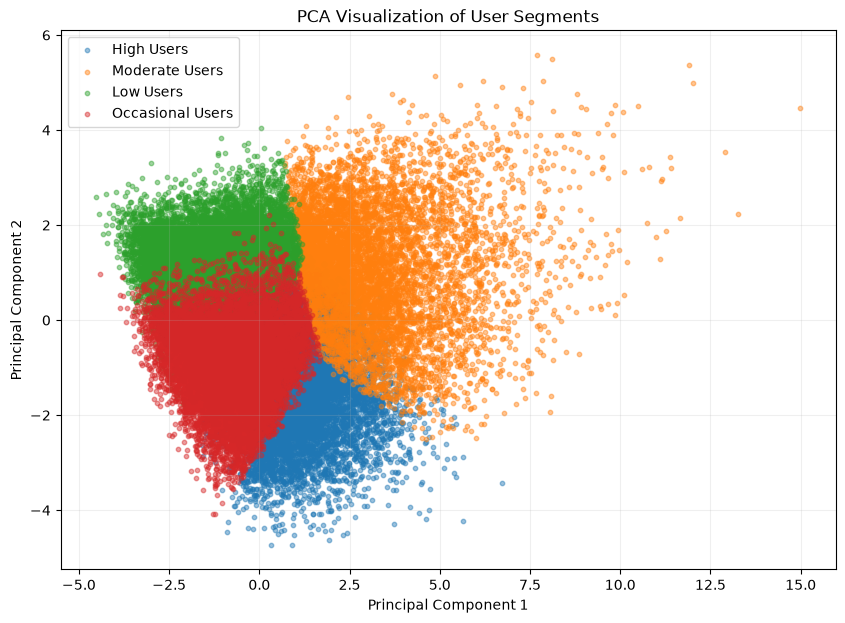

In [44]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_clean["pca_1"] = X_pca[:, 0]
df_clean["pca_2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

fig, ax = plt.subplots(figsize=(10, 7))

for segment in segment_order:
    subset = df_clean[df_clean["segment_name"] == segment]
    ax.scatter(
        subset["pca_1"],
        subset["pca_2"],
        s=10,
        alpha=0.45,
        label=segment
    )

ax.set_title("PCA Visualization of User Segments")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 14. Business Insight Generation & Customer Action Mapping

Map each segment to a business objective and recommended action. These actions are tied to the behavioral meaning of the segment and are not used to train the model.

In [45]:
business_actions = {
    "High Users": {
        "customer_characteristics": (
            "Highly active users with strong engagement and frequent interaction "
            "with the application."
        ),
        "business_value": (
            "Important users for loyalty, continued engagement, and value expansion."
        ),
        "recommended_action": (
            "Use loyalty programs, premium offers, exclusive features, and "
            "personalized recommendations to maintain engagement and increase value."
        )
    },
    "Moderate Users": {
        "customer_characteristics": (
            "Users with consistent but moderate activity and balanced engagement."
        ),
        "business_value": (
            "Users with an opportunity for increased engagement and progression "
            "toward higher-value behavior."
        ),
        "recommended_action": (
            "Use personalized recommendations, feature discovery campaigns, "
            "targeted incentives, and engagement journeys."
        )
    },
    "Low Users": {
        "customer_characteristics": (
            "Users with low activity and engagement and comparatively weaker "
            "retention health."
        ),
        "business_value": (
            "A key retention opportunity where timely intervention may reduce "
            "disengagement and potential churn."
        ),
        "recommended_action": (
            "Use re-engagement campaigns, personalized notifications, win-back "
            "offers, and targeted retention journeys."
        )
    },
    "Occasional Users": {
        "customer_characteristics": (
            "Users who interact with the application irregularly or infrequently."
        ),
        "business_value": (
            "An opportunity to increase usage frequency and encourage more "
            "consistent application engagement."
        ),
        "recommended_action": (
            "Use relevant reminders, personalized content, targeted promotions, "
            "and recommendations designed to increase visit frequency."
        )
    }
}

business_action_df = pd.DataFrame.from_dict(
    business_actions,
    orient="index"
).reset_index().rename(columns={"index": "segment_name"})

display(business_action_df)

,segment_name,customer_characteristics,business_value,recommended_action
0,High Users,Highly active users with strong engagement and...,"Important users for loyalty, continued engagem...","Use loyalty programs, premium offers, exclusiv..."
1,Moderate Users,Users with consistent but moderate activity an...,Users with an opportunity for increased engage...,"Use personalized recommendations, feature disc..."
2,Low Users,Users with low activity and engagement and com...,A key retention opportunity where timely inter...,"Use re-engagement campaigns, personalized noti..."
3,Occasional Users,Users who interact with the application irregu...,An opportunity to increase usage frequency and...,"Use relevant reminders, personalized content, ..."


## 15. Final Business Summary

Combine the behavioral profile, dynamic performance scores, customer count, and recommended business action into a single reporting table.

In [46]:
summary = (
    segment_profile.reset_index()
    .merge(
        business_action_df,
        on="segment_name",
        how="left"
    )
)

summary["segment_order"] = summary["segment_name"].map({
    "High Users": 1,
    "Moderate Users": 2,
    "Low Users": 3,
    "Occasional Users": 4
})

summary = summary.sort_values("segment_order").drop(columns="segment_order")

display(summary)

,cluster,segment_name,days_active,total_sessions,avg_session_duration_min,screen_views,clicks,likes,shares,comments,searches,notification_open_rate,purchases,total_spend,retained_30d,churn_risk_score,user_count,percentage_of_users,activity_score,value_score,retention_score,overall_behavior_score,customer_characteristics,business_value,recommended_action
0,0,High Users,175.603,30.222,11.980,227.860,41.027,8.062,0.518,0.922,12.028,0.285,2.238,89.400,0.378,0.186,10297,20.59,0.411694,1.162468,0.426511,0.6031,Highly active users with strong engagement and...,"Important users for loyalty, continued engagem...","Use loyalty programs, premium offers, exclusiv..."
2,2,Moderate Users,119.418,27.863,12.114,247.219,58.303,19.064,2.339,3.517,11.975,0.284,2.234,88.501,0.366,0.302,7295,14.59,0.806419,0.779112,-0.083581,0.5771,Users with consistent but moderate activity an...,Users with an opportunity for increased engage...,"Use personalized recommendations, feature disc..."
1,1,Low Users,89.020,23.027,11.981,151.071,26.248,5.494,0.302,0.562,12.012,0.285,2.194,85.879,0.000,0.496,19871,39.74,-0.536634,-0.883980,-1.418031,-0.8438,Users with low activity and engagement and com...,A key retention opportunity where timely inter...,"Use re-engagement campaigns, personalized noti..."
3,3,Occasional Users,92.386,23.092,12.060,150.303,25.710,5.459,0.294,0.550,12.003,0.283,2.177,86.329,1.000,0.237,12537,25.07,-0.681479,-1.057601,1.075101,-0.3364,Users who interact with the application irregu...,An opportunity to increase usage frequency and...,"Use relevant reminders, personalized content, ..."


## 16. Final Validation

Validate the complete project before generating the final outputs. The validation confirms that all users are assigned, all four business segments exist, and the dynamic mapping is internally consistent.

In [47]:
# Core data validation.
assert len(df_clean) > 0
assert df_clean[USER_ID_COL].nunique() == len(df_clean)
assert df_clean["cluster"].nunique() == 4
assert df_clean["segment_name"].notna().all()
assert df_clean["segment_name"].nunique() == 4
assert set(df_clean["segment_name"].unique()) == expected_segments

# Mapping validation.
assert len(segment_mapping) == 4
assert len(set(segment_mapping.values())) == 4
assert cluster_performance["overall_behavior_score"].notna().all()

# Customer coverage validation.
assigned_counts = (
    df_clean["segment_name"]
    .value_counts()
    .reindex(segment_order)
)

assert assigned_counts.notna().all()
assert assigned_counts.sum() == len(df_clean)

print("FINAL VALIDATION PASSED")
print(f"Users: {len(df_clean):,}")
print(f"Clusters: {df_clean['cluster'].nunique()}")
print(f"Segments: {df_clean['segment_name'].nunique()}")
print(f"Unassigned users: {df_clean['segment_name'].isna().sum()}")

display(
    pd.DataFrame({
        "segment_name": segment_order,
        "user_count": assigned_counts.values,
        "percentage_of_users": (
            assigned_counts.values / len(df_clean) * 100
        ).round(2)
    })
)

print("\nDynamic mapping:")
for cluster_id, segment_name in sorted(segment_mapping.items()):
    print(f"Cluster {cluster_id} -> {segment_name}")

FINAL VALIDATION PASSED
Users: 50,000
Clusters: 4
Segments: 4
Unassigned users: 0


,segment_name,user_count,percentage_of_users
0,High Users,10297,20.59
1,Moderate Users,7295,14.59
2,Low Users,19871,39.74
3,Occasional Users,12537,25.07



Dynamic mapping:
Cluster 0 -> High Users
Cluster 1 -> Low Users
Cluster 2 -> Moderate Users
Cluster 3 -> Occasional Users


## 17. Save Project Outputs

Save clean, consistent outputs for reporting and the future Streamlit dashboard. The dashboard should use `cluster_performance.csv` and `segmented_users.csv` as the authoritative sources for cluster-to-segment mapping and customer-level assignments.

In [48]:
# 1. Final segmented user dataset.
segmented_users = df_clean.copy()
segmented_users.to_csv(
    OUTPUT_DIR / "segmented_users.csv",
    index=False
)

# 2. Cluster performance and dynamic mapping.
cluster_performance.reset_index().rename(
    columns={"index": "cluster"}
).to_csv(
    OUTPUT_DIR / "cluster_performance.csv",
    index=False
)

# 3. Segment profile.
segment_profile.reset_index().to_csv(
    OUTPUT_DIR / "final_segment_profile.csv",
    index=False
)

# 4. Segment distribution.
segment_distribution = (
    df_clean["segment_name"]
    .value_counts()
    .reindex(segment_order)
    .rename_axis("segment_name")
    .reset_index(name="user_count")
)

segment_distribution["percentage_of_users"] = (
    segment_distribution["user_count"] / len(df_clean) * 100
).round(2)

segment_distribution.to_csv(
    OUTPUT_DIR / "segment_distribution.csv",
    index=False
)

# 5. Business action mapping.
business_action_df.to_csv(
    OUTPUT_DIR / "business_action_mapping.csv",
    index=False
)

# 6. Final business summary.
summary.to_csv(
    OUTPUT_DIR / "final_business_summary.csv",
    index=False
)

# 7. Individual segment customer lists.
file_names = {
    "High Users": "high_users.csv",
    "Moderate Users": "moderate_users.csv",
    "Low Users": "low_users.csv",
    "Occasional Users": "occasional_users.csv"
}

for segment, filename in file_names.items():
    df_clean[df_clean["segment_name"] == segment].to_csv(
        OUTPUT_DIR / filename,
        index=False
    )

# 8. Model-selection metrics.
model_metrics.to_csv(
    OUTPUT_DIR / "clustering_metrics.csv",
    index=False
)

# 9. PCA coordinates.
df_clean[
    [USER_ID_COL, "cluster", "segment_name", "pca_1", "pca_2"]
].to_csv(
    OUTPUT_DIR / "pca_coordinates.csv",
    index=False
)

print("All output files saved to:", OUTPUT_DIR)

All output files saved to: d:\app-user-behavior-segmentation\outputs


## 18. Save Model Artifacts

Save the trained K-Means model, scaler, PCA model, and selected feature list so the clustering pipeline can be reused.

In [49]:
joblib.dump(
    kmeans,
    MODEL_DIR / "kmeans_model.joblib"
)

joblib.dump(
    scaler,
    MODEL_DIR / "scaler.joblib"
)

joblib.dump(
    pca,
    MODEL_DIR / "pca_model.joblib"
)

with open(MODEL_DIR / "cluster_features.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(selected_features))

with open(MODEL_DIR / "segment_mapping.txt", "w", encoding="utf-8") as f:
    for cluster_id, segment_name in sorted(segment_mapping.items()):
        f.write(f"Cluster {cluster_id} -> {segment_name}\n")

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


## 19. Final Output Verification

Confirm that the files required by the project and future Streamlit dashboard exist.

In [50]:
required_outputs = [
    "segmented_users.csv",
    "cluster_performance.csv",
    "final_segment_profile.csv",
    "segment_distribution.csv",
    "business_action_mapping.csv",
    "final_business_summary.csv",
    "high_users.csv",
    "moderate_users.csv",
    "low_users.csv",
    "occasional_users.csv",
    "clustering_metrics.csv",
    "pca_coordinates.csv"
]

required_models = [
    "kmeans_model.joblib",
    "scaler.joblib",
    "pca_model.joblib",
    "cluster_features.txt",
    "segment_mapping.txt"
]

print("OUTPUT FILES")
for filename in required_outputs:
    path = OUTPUT_DIR / filename
    print(f"{filename:35} {'OK' if path.exists() else 'MISSING'}")

print("\nMODEL FILES")
for filename in required_models:
    path = MODEL_DIR / filename
    print(f"{filename:35} {'OK' if path.exists() else 'MISSING'}")

OUTPUT FILES
segmented_users.csv                 OK
cluster_performance.csv             OK
final_segment_profile.csv           OK
segment_distribution.csv            OK
business_action_mapping.csv         OK
final_business_summary.csv          OK
high_users.csv                      OK
moderate_users.csv                  OK
low_users.csv                       OK
occasional_users.csv                OK
clustering_metrics.csv              OK
pca_coordinates.csv                 OK

MODEL FILES
kmeans_model.joblib                 OK
scaler.joblib                       OK
pca_model.joblib                    OK
cluster_features.txt                OK
segment_mapping.txt                 OK


# Project Result

The completed notebook provides:

### 1. Successful User Segmentation
K-Means clustering segments the app users into four behavioral groups without using a labeled target variable.

### 2. Behavior-Based Segment Names
The four business names — **High Users, Moderate Users, Low Users, and Occasional Users** — are assigned from observed cluster performance rather than arbitrary K-Means cluster IDs.

### 3. Clear Behavioral Profiling
Each segment is profiled using activity, engagement, value, retention, and churn-related measures available in the dataset.

### 4. Customer-Level Identification
Every user is mapped to:

`User ID → Cluster → Business Segment`

### 5. Business-Actionable Insights
Each segment receives a business interpretation, business value, and recommended action.

### 6. Scalable Project Output
The notebook produces reusable CSV and model artifacts for reporting and Streamlit dashboard integration.

## Important Dashboard Rule

The future Streamlit application should **not hard-code cluster numbers to segment names** and should **not rely on an old segment-name column**.

It should use:

- `cluster_performance.csv` for the authoritative cluster → segment mapping.
- `segmented_users.csv` for user → cluster → segment assignments.
- `final_segment_profile.csv` for segment metrics.
- `business_action_mapping.csv` for business actions.

This keeps the dashboard consistent with the actual clustering results.